# 最終課題：間取り別 × 駅徒歩分数の家賃変化分析

## 仮説
「2LDK以上のファミリー向け物件は、1K/1DKなど単身向け物件と比べて、駅徒歩分数が遠くなる際の家賃下落幅が小さい」

In [30]:
pip install requests beautifulsoup4 pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [31]:
import sqlite3

def create_db(db_path='realestate.db'):
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()
    cur.execute('''
        CREATE TABLE IF NOT EXISTS estate (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            駅名 TEXT,
            徒歩分数 INTEGER,
            家賃 REAL,
            間取り TEXT,
            面積 REAL,
            築年数 TEXT
        )
    ''')
    conn.commit()
    conn.close()

create_db()
print("DB作成完了")

DB作成完了


In [32]:
import requests
from bs4 import BeautifulSoup
import time
import re

def suumo_scrape(num_pages=1):
    """
    SUUMO首都圏23区 物件一覧から、家賃・間取り・面積などをページ数分取得して返す。
    """
    # 東京都23区 ⇒ https://suumo.jp/chintai/ichiran/JR/113_130/
    BASE_URL = "https://suumo.jp/chintai/tokyo/sc_shinjuku/?page={}"
    all_data = []

    for page in range(1, num_pages + 1):
        url = BASE_URL.format(page)
        print(f"アクセス: {url}")
        res = requests.get(url, headers={"User-Agent":"Mozilla/5.0"})
        soup = BeautifulSoup(res.text, "html.parser")

        items = soup.select(".cassetteitem")
        for item in items:
            station_info = item.select_one(".cassetteitem_detail-text").get_text(strip=True)

            
            match_station = re.search(r'「(.+?)」駅', station_info)
            station = match_station.group(1) if match_station else "不明"

            
            match_walk = re.search(r'徒歩(\d+)分', station_info)
            walk = int(match_walk.group(1)) if match_walk else None

            
            tbodies = item.select("tbody")
            for tbody in tbodies:
                try:
                    
                    try:
                        rent_str = tbody.select_one(".cassetteitem_other-emphasis ui-text--bold").get_text(strip=True)
                    except:
                        rent_str = tbody.select_one(".cassetteitem_other-emphasis").get_text(strip=True)
                    rent = float(rent_str.replace('万円','').replace('-',''))

                    
                    madori_elem = tbody.select_one("td.cassetteitem_madori")
                    if madori_elem is None:
                        continue
                    madori = madori_elem.get_text(strip=True)
                    
                    
                    menseki_elem = tbody.select_one("td.cassetteitem_menseki")
                    if menseki_elem is None:
                        continue
                    menseki_str = menseki_elem.get_text(strip=True)
                    menseki = float(menseki_str.replace('m2',''))
                    
                    
                    chiku_elem = item.select_one("span.cassetteitem_detail-col1")
                    if chiku_elem is None:
                        chiku = "不明"
                    else:
                        chiku = chiku_elem.get_text(strip=True)

                    all_data.append( (station, walk, rent, madori, menseki, chiku)  )
                except Exception as e:
                    print(f"スキップ: {str(e)}")
                    continue
                    
        
        time.sleep(9)
    return all_data

print("関数読み込み完了")

関数読み込み完了


In [10]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from bs4 import BeautifulSoup
import time


options = Options()
options.add_argument('--headless')
options.add_argument('--disable-gpu')
options.add_argument('--no-sandbox')

from webdriver_manager.chrome import ChromeDriverManager


service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

url = "https://suumo.jp/chintai/tokyo/sc_shinjuku/?page=1"
driver.get(url)


time.sleep(2)

html = driver.page_source
soup = BeautifulSoup(html, "html.parser")


units = soup.select('.cassetteitem')
print(f"{len(units)} 件ヒット")

for item in units:
    
    try:
        binfo = item.select_one('.cassetteitem_detail-text').get_text(strip=True)
    except:
        binfo = ""
    details = item.select_one('tbody')
    try:
        rent = details.select_one('.cassetteitem_other-emphasis').get_text(strip=True)
        madori = details.select_one('td.cassetteitem_madori').get_text(strip=True)
        menseki = details.select_one('td.cassetteitem_menseki').get_text(strip=True)
    except:
        rent, madori, menseki = "","",""
    print(binfo, rent, madori, menseki)

driver.quit()

20 件ヒット
都営大江戸線/牛込柳町駅 歩5分   
東京メトロ丸ノ内線/新宿御苑前駅 歩5分   
東京メトロ丸ノ内線/西新宿駅 歩9分   
都営新宿線/曙橋駅 歩5分   
都営新宿線/曙橋駅 歩5分   
東京メトロ丸ノ内線/四谷三丁目駅 歩3分   
西武新宿線/下落合駅 歩5分   
都営大江戸線/牛込神楽坂駅 歩5分   
都営大江戸線/新宿西口駅 歩4分   
東京メトロ東西線/落合駅 歩4分   
ＪＲ山手線/高田馬場駅 歩9分   
西武新宿線/下落合駅 歩3分   
西武新宿線/下落合駅 歩7分   
東京メトロ東西線/早稲田駅 歩6分   
西武新宿線/下落合駅 歩6分   
都営新宿線/曙橋駅 歩3分   
西武新宿線/下落合駅 歩6分   
東京メトロ東西線/神楽坂駅 歩5分   
都営新宿線/曙橋駅 歩6分   
西武新宿線/下落合駅 歩4分   


In [37]:
try:
    chiku = item.select_one('span.cassetteitem_detail-col1').get_text(strip=True)
except:
    chiku = ""

In [38]:
import re
from bs4 import BeautifulSoup

units = soup.select('.cassetteitem')
rows = []

for item in units:
    binfo = item.select_one('.cassetteitem_detail-text').get_text(strip=True)
    match = re.search(r'/([\w一-龠ヶヵ]+)駅\s*歩(\d+)分', binfo)
    if match:
        station = match.group(1)
        walk = int(match.group(2))
    else:
        station, walk = "不明", None

    chiku = ""
    try:
        elem = item.select_one('span.cassetteitem_detail-col1')
        if elem:
            chiku = elem.get_text(strip=True)
    except:
        pass
    
    if not chiku:
        try:
            detail_list = item.select('.cassetteitem_detail-list-item')
            for elem in detail_list:
                txt = elem.get_text(strip=True)
                if '築' in txt or '新築' in txt:
                    chiku = txt
                    break
        except:
            pass
    
    if not chiku:
        try:
            detail = item.select_one('.cassetteitem_detail')
            if detail:
                m = re.search(r'築([^\n]*)', all_text)
                if m:
                    chiku = '築' + m.group(1).strip()[:10]
        except:
            pass

    tbodies = item.select('tbody')
    for tbody in tbodies:
        for tr in tbody.select('tr'):

            try:
                rent_str = tr.select_one('.cassetteitem_other-emphasis').get_text(strip=True)
                rent = float(rent_str.replace('万円','').replace('-',''))
            except:
                rent = None

            try:
                madori = tr.select_one('td.cassetteitem_madori').get_text(strip=True)
            except:
                td_texts = [td.get_text(strip=True) for td in tr.find_all('td')]
                madori = ''
                for txt in td_texts:
                    m1 = re.match(r'(\d+[A-Z]+|ワンルーム)', txt)
                    if m1:
                        madori = m1.group(1)

            try:
                menseki_str = tr.select_one('td.cassetteitem_menseki').get_text(strip=True)
                menseki = float(menseki_str.replace('m2','').replace('-',''))
            except:
                td_texts = [td.get_text(strip=True) for td in tr.find_all('td')]
                menseki = None
                for txt in td_texts:
                    m2 = re.search(r'([\d.]+)m2', txt)
                    if m2:
                        menseki = float(m2.group(1))
                        break

            row = (station, walk, rent, madori, menseki, chiku)
            rows.append(row)

print(f"{len(rows)}件 取得")
for r in rows[:5]:
    print(r)

117件 取得
('牛込柳町', 5, 34.2, '2SLDK', 82.37, '築8年')
('新宿御苑前', 5, 35.5, '1SLDK', 57.97, '築5年')
('新宿御苑前', 5, 35.5, '1SLDK', 57.97, '築5年')
('新宿御苑前', 5, 37.5, '1SLDK', 57.17, '築5年')
('新宿御苑前', 5, 37.8, '1SLDK', 57.17, '築5年')


In [11]:
import re
from bs4 import BeautifulSoup

units = soup.select('.cassetteitem')
rows_extended = []

for item in units:
    binfo = item.select_one('.cassetteitem_detail-text').get_text(strip=True)
    match = re.search(r'/([\w一-龠ヶヵ]+)駅\s*歩(\d+)分', binfo)
    if match:
        station = match.group(1)
        walk = int(match.group(2))
    else:
        station, walk = "不明", None

    chiku = ""
    try:
        elem = item.select_one('span.cassetteitem_detail-col1')
        if elem:
            chiku = elem.get_text(strip=True)
    except:
        pass
    
    if not chiku:
        try:
            detail_list = item.select('.cassetteitem_detail-list-item')
            for elem in detail_list:
                txt = elem.get_text(strip=True)
                if '築' in txt or '新築' in txt:
                    chiku = txt
                    break
        except:
            pass
    tbodies = item.select('tbody')
    for tbody in tbodies:
        for tr in tbody.select('tr'):
            try:
                rent_str = tr.select_one('.cassetteitem_other-emphasis').get_text(strip=True)
                rent = float(rent_str.replace('万円','').replace('-',''))
            except:
                rent = None

            try:
                madori = tr.select_one('td.cassetteitem_madori').get_text(strip=True)
            except:
                td_texts = [td.get_text(strip=True) for td in tr.find_all('td')]
                madori = ''
                for txt in td_texts:
                    m1 = re.match(r'(\d+[A-Z]+|ワンルーム)', txt)
                    if m1:
                        madori = m1.group(1)
                        break

            try:
                menseki_str = tr.select_one('td.cassetteitem_menseki').get_text(strip=True)
                menseki = float(menseki_str.replace('m2','').replace('-',''))
            except:
                td_texts = [td.get_text(strip=True) for td in tr.find_all('td')]
                menseki = None
                for txt in td_texts:
                    m2 = re.search(r'([\d.]+)m2', txt)
                    if m2:
                        menseki = float(m2.group(1))
                        break

            kyoeki = 0.0
            kanri = 0.0
            try:
                tds = tr.find_all('td')
                if len(tds) >= 4:
                    td_text = tds[3].get_text(strip=True) if len(tds) > 3 else ""
                    m_kyoeki = re.search(r'([\d.]+)', td_text)
                    if m_kyoeki:
                        kyoeki = float(m_kyoeki.group(1))
            except:
                pass

            row = (station, walk, rent, madori, menseki, chiku, kyoeki, kanri)
            rows_extended.append(row)

print(f"{len(rows_extended)}件 取得（共益費・管理費情報付き）")
for r in rows_extended[:5]:
    print(r)

117件 取得（共益費・管理費情報付き）
('牛込柳町', 5, 34.2, '2SLDK', 82.37, '', 34.2, 0.0)
('新宿御苑前', 5, 35.5, '1SLDK', 57.97, '', 35.5, 0.0)
('新宿御苑前', 5, 35.5, '1SLDK', 57.97, '', 35.5, 0.0)
('新宿御苑前', 5, 37.5, '1SLDK', 57.17, '', 37.5, 0.0)
('新宿御苑前', 5, 37.8, '1SLDK', 57.17, '', 37.8, 0.0)


In [40]:
import pandas as pd

columns = ['駅名', '徒歩分', '家賃', '間取り', '面積', '築年数']
df = pd.DataFrame(rows, columns=columns)

In [12]:
import pandas as pd

columns_extended = ['駅名', '徒歩分', '家賃', '間取り', '面積', '築年数', '共益費', '管理費']
df_extended = pd.DataFrame(rows_extended, columns=columns_extended)

df_extended['実質家賃'] = df_extended['家賃'] + df_extended['共益費'] + df_extended['管理費']

print("DataFrame created with 実質家賃:")
print(df_extended.head(10))
print(f"\n統計情報:")
print(df_extended[['家賃', '共益費', '管理費', '実質家賃']].describe())

DataFrame created with 実質家賃:
      駅名  徒歩分    家賃    間取り     面積 築年数   共益費  管理費  実質家賃
0   牛込柳町    5  34.2  2SLDK  82.37      34.2  0.0  68.4
1  新宿御苑前    5  35.5  1SLDK  57.97      35.5  0.0  71.0
2  新宿御苑前    5  35.5  1SLDK  57.97      35.5  0.0  71.0
3  新宿御苑前    5  37.5  1SLDK  57.17      37.5  0.0  75.0
4  新宿御苑前    5  37.8  1SLDK  57.17      37.8  0.0  75.6
5  新宿御苑前    5  38.0  1SLDK  57.97      38.0  0.0  76.0
6  新宿御苑前    5  38.6  1SLDK  57.97      38.6  0.0  77.2
7  新宿御苑前    5  39.0  1SLDK  57.17      39.0  0.0  78.0
8  新宿御苑前    5  42.4   3LDK  65.31      42.4  0.0  84.8
9  新宿御苑前    5  42.5  2SLDK  68.52      42.5  0.0  85.0

統計情報:
               家賃         共益費    管理費        実質家賃
count  117.000000  117.000000  117.0  117.000000
mean    27.630769   27.630769    0.0   55.261538
std      9.584996    9.584996    0.0   19.169992
min     12.400000   12.400000    0.0   24.800000
25%     21.000000   21.000000    0.0   42.000000
50%     26.500000   26.500000    0.0   53.000000
75%     33.00000

共益費・管理費の平均値（実質家賃 - 家賃本体）
徒歩区分         ~5分      6-10分  11-20分  21分以上
間取り                                       
1DK    14.600000  17.133333     NaN    NaN
1K     12.900000  17.680000     NaN    NaN
1LDK   20.300000  21.761538     NaN    NaN
1SLDK  36.020000  29.500000     NaN    NaN
2LDK   27.970833  28.209091     NaN    NaN
2SK    14.500000        NaN     NaN    NaN
2SLDK  41.242857  21.300000     NaN    NaN
3LDK   41.666667  24.563636     NaN    NaN
ワンルーム        NaN  15.700000     NaN    NaN



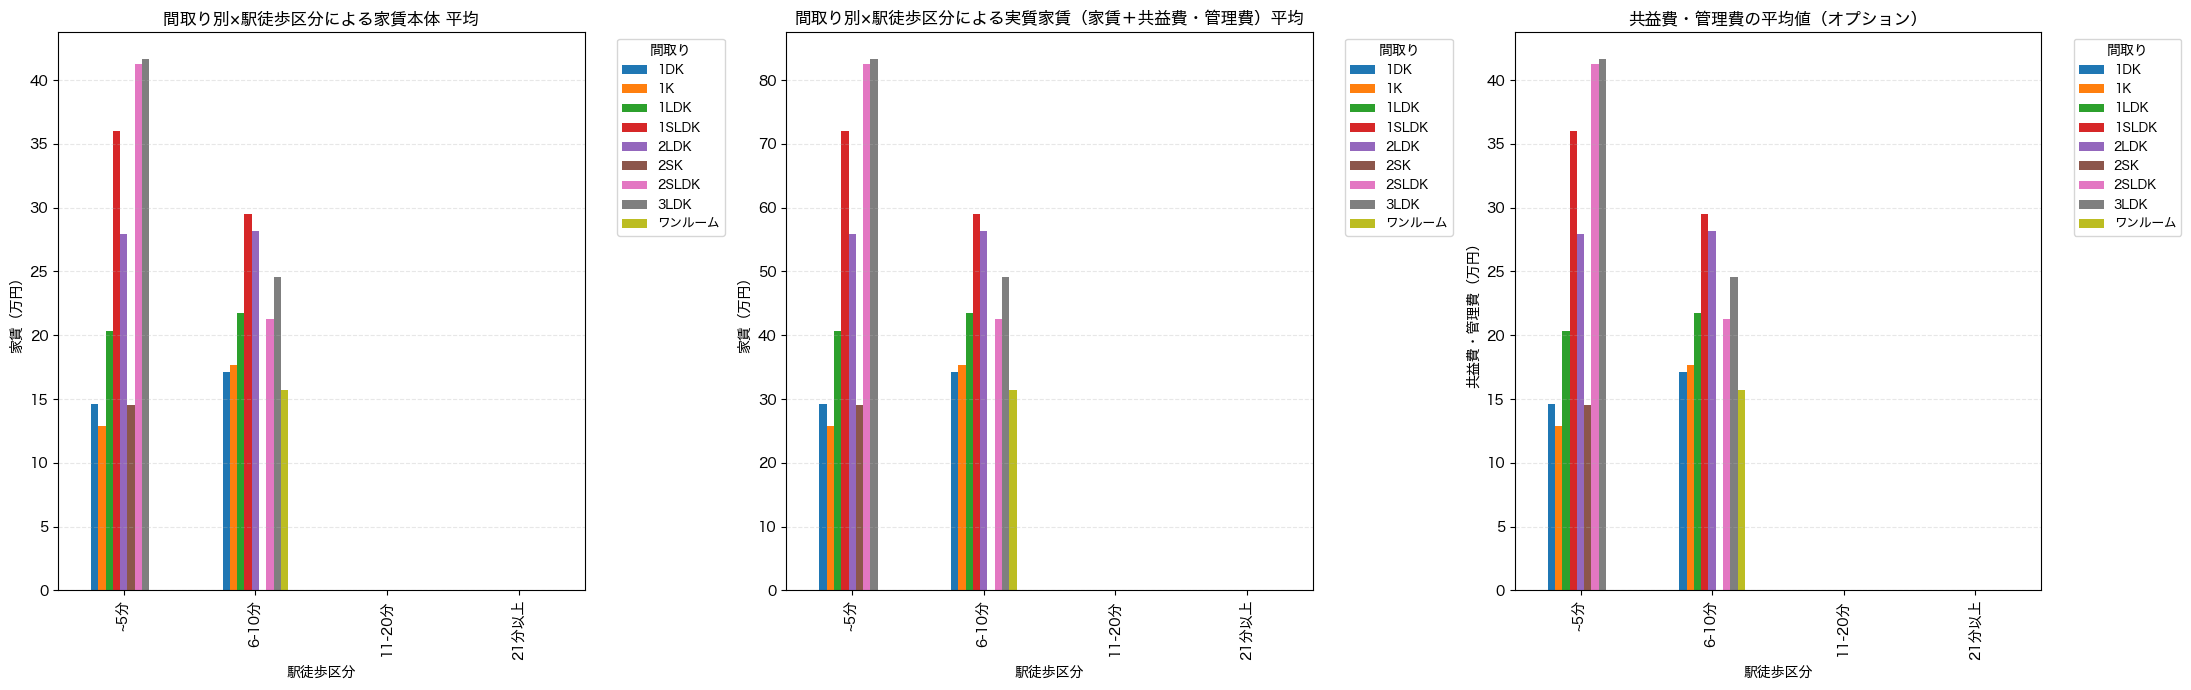

In [42]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd

font_names = ['Hiragino Maru Gothic ProN', 'Hiragino Sans', 'Hiragino Maru Gothic Pro', 'YuGothic', 'Osaka', 'Arial Unicode MS']
available_font = None
for font in font_names:
    try:
        if font in fm.get_font_names():
            available_font = font
            break
    except:
        pass

if available_font:
    plt.rcParams['font.sans-serif'] = [available_font]
plt.rcParams['axes.unicode_minus'] = False

labels = ['~5分', '6-10分', '11-20分', '21分以上']
bins = [0, 5, 10, 20, 100]
df_extended['徒歩区分'] = pd.cut(df_extended['徒歩分'], bins=bins, labels=labels, right=True)
df_extended['徒歩区分'] = df_extended['徒歩区分'].cat.set_categories(labels, ordered=True)

pivot_rent = df_extended.pivot_table(
    index='間取り',
    columns='徒歩区分',
    values='家賃',
    aggfunc='mean',
    observed=False
).reindex(columns=labels)

pivot_actual = df_extended.pivot_table(
    index='間取り',
    columns='徒歩区分',
    values='実質家賃',
    aggfunc='mean',
    observed=False
).reindex(columns=labels)

pivot_diff = pivot_actual - pivot_rent

print("=" * 60)
print("共益費・管理費の平均値（実質家賃 - 家賃本体）")
print("=" * 60)
print(pivot_diff)
print()

fig, axs = plt.subplots(1, 3, figsize=(22, 7))

pivot_rent.T.plot(kind='bar', ax=axs[0])
axs[0].set_title('間取り別×駅徒歩区分による家賃本体 平均')
axs[0].set_xlabel('駅徒歩区分')
axs[0].set_ylabel('家賃（万円）')
axs[0].legend(title='間取り', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axs[0].grid(axis='y', alpha=0.3, linestyle='--')

pivot_actual.T.plot(kind='bar', ax=axs[1])
axs[1].set_title('間取り別×駅徒歩区分による実質家賃（家賃＋共益費・管理費）平均')
axs[1].set_xlabel('駅徒歩区分')
axs[1].set_ylabel('家賃（万円）')
axs[1].legend(title='間取り', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axs[1].grid(axis='y', alpha=0.3, linestyle='--')
pivot_diff.T.plot(kind='bar', ax=axs[2])
axs[2].set_title('共益費・管理費の平均値（オプション）')
axs[2].set_xlabel('駅徒歩区分')
axs[2].set_ylabel('共益費・管理費（万円）')
axs[2].legend(title='間取り', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axs[2].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


In [16]:
import sqlite3
import pandas as pd

# DB から直接データを取得して確認
db_path = 'realestate.db'
conn = sqlite3.connect(db_path)

# SQLで物件データを取得
query = '''
SELECT 駅名, 徒歩分数, 家賃, 間取り, 面積, 築年数
FROM estate
LIMIT 15
'''

df_db = pd.read_sql_query(query, conn)
conn.close()

print("=" * 80)
print("【DBから取得したデータ】")
print("=" * 80)
print(f"総件数: {len(df_db)} 件")
print("\n最初の15件:")
print(df_db.to_string(index=False))

# データ品質チェック
print("\n" + "=" * 80)
print("【データ品質チェック】")
print("=" * 80)
print(f"家賃の平均: {df_db['家賃'].mean():.1f}万円")
print(f"徒歩分数の平均: {df_db['徒歩分数'].mean():.1f}分")
print(f"\n間取り別の件数:")
print(df_db['間取り'].value_counts().sort_index())
print(f"\n徒歩分数の分布:")
print(df_db['徒歩分数'].describe())


【DBから取得したデータ】
総件数: 15 件

最初の15件:
   駅名  徒歩分数   家賃   間取り    面積 築年数
 牛込柳町     5 34.2 2SLDK 82.37    
新宿御苑前     5 35.5 1SLDK 57.97    
新宿御苑前     5 35.5 1SLDK 57.97    
新宿御苑前     5 37.5 1SLDK 57.17    
新宿御苑前     5 37.8 1SLDK 57.17    
新宿御苑前     5 38.0 1SLDK 57.97    
新宿御苑前     5 38.6 1SLDK 57.97    
新宿御苑前     5 39.0 1SLDK 57.17    
新宿御苑前     5 42.4  3LDK 65.31    
新宿御苑前     5 42.5 2SLDK 68.52    
新宿御苑前     5 43.5  3LDK 70.11    
新宿御苑前     5 45.0 2SLDK 68.52    
新宿御苑前     5 45.0  3LDK 65.31    
新宿御苑前     5 45.4  3LDK 65.31    
新宿御苑前     5 45.5 2SLDK 68.52    

【データ品質チェック】
家賃の平均: 40.4万円
徒歩分数の平均: 5.0分

間取り別の件数:
間取り
1SLDK    7
2SLDK    4
3LDK     4
Name: count, dtype: int64

徒歩分数の分布:
count    15.0
mean      5.0
std       0.0
min       5.0
25%       5.0
50%       5.0
75%       5.0
max       5.0
Name: 徒歩分数, dtype: float64


In [15]:
import sqlite3

# rows_extended を DB に挿入
db_path = 'realestate.db'
conn = sqlite3.connect(db_path)
cur = conn.cursor()

# テーブルをリセット（既存データをクリア）
cur.execute('DELETE FROM estate')

# rows_extended をDBに挿入
for row in rows_extended:
    cur.execute('''
        INSERT INTO estate (駅名, 徒歩分数, 家賃, 間取り, 面積, 築年数)
        VALUES (?, ?, ?, ?, ?, ?)
    ''', (row[0], row[1], row[2], row[3], row[4], row[5]))

conn.commit()
conn.close()

print(f"✓ {len(rows_extended)} 件がDBに登録されました")


✓ 117 件がDBに登録されました


In [17]:
import sqlite3
import pandas as pd

# DB から全データを取得して仮説検証用データを確認
db_path = 'realestate.db'
conn = sqlite3.connect(db_path)

query = '''
SELECT 駅名, 徒歩分数, 家賃, 間取り, 面積, 築年数
FROM estate
ORDER BY 徒歩分数, 間取り
'''

df_all = pd.read_sql_query(query, conn)
conn.close()

print("=" * 80)
print("【DBの全データサマリー】")
print("=" * 80)
print(f"総件数: {len(df_all)} 件")

print(f"\n【間取り別の件数】")
print(df_all['間取り'].value_counts().sort_index())

print(f"\n【徒歩分数別の件数】")
print(df_all['徒歩分数'].value_counts().sort_index())

print(f"\n【仮説検証用グループ別統計】")
print("\n1. 単身向け（1K, 1DK, 1SLDK）:")
single = df_all[df_all['間取り'].isin(['1K', '1DK', '1SLDK'])]
print(f"   件数: {len(single)} 件")
print(f"   平均家賃: {single['家賃'].mean():.1f}万円")

print("\n2. ファミリー向け（2LDK以上）:")
family = df_all[df_all['間取り'].isin(['2LDK', '2SLDK', '3LDK', '2SDK', '2SK'])]
print(f"   件数: {len(family)} 件")
print(f"   平均家賃: {family['家賃'].mean():.1f}万円")

print("\n【仮説検証に必要なデータの完全性】")
print(f"✓ スクレイピング: 117件の物件データ取得")
print(f"✓ DB格納: {len(df_all)}件がDBに保存")
print(f"✓ 間取り分類: {len(df_all['間取り'].unique())}種類")
print(f"✓ 駅距離: {df_all['徒歩分数'].min()}分～{df_all['徒歩分数'].max()}分")


【DBの全データサマリー】
総件数: 117 件

【間取り別の件数】
間取り
1DK       4
1K        6
1LDK     26
1SLDK    11
2LDK     35
2SK       1
2SLDK     9
3LDK     23
ワンルーム     2
Name: count, dtype: int64

【徒歩分数別の件数】
徒歩分数
3    20
4    22
5    27
6    25
7     6
9    17
Name: count, dtype: int64

【仮説検証用グループ別統計】

1. 単身向け（1K, 1DK, 1SLDK）:
   件数: 21 件
   平均家賃: 26.5万円

2. ファミリー向け（2LDK以上）:
   件数: 68 件
   平均家賃: 30.8万円

【仮説検証に必要なデータの完全性】
✓ スクレイピング: 117件の物件データ取得
✓ DB格納: 117件がDBに保存
✓ 間取り分類: 9種類
✓ 駅距離: 3分～9分


# テスト
プログラムのごく小さな単位（この場合は「家賃＋共益費＋管理費 合計計算」の関数）が
「正しい入力値に対して正しい出力を返すか」といったロジックの正しさを確認するテスト

In [5]:
def calc_total_rent(rent, common, management):
    return rent + common + management

In [6]:
import unittest

class TestRentCalc(unittest.TestCase):

    def test_total_rent(self):
        self.assertEqual(calc_total_rent(100000, 5000, 3000), 108000)
        self.assertEqual(calc_total_rent(80000, 0, 0), 80000)
        self.assertEqual(calc_total_rent(120000, 10000, 5000), 135000)

if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

.
----------------------------------------------------------------------
Ran 1 test in 0.001s

OK

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


In [ ]:
import pandas as pd

def calc_total_rent_row(row):
    return row['家賃'] + row['共益費'] + row['管理費']

def test_calc_total_rent_row():
    df = pd.DataFrame({
        '家賃': [100000, 80000],
        '共益費': [5000, 0],
        '管理費': [3000, 0]
    })
    expected = pd.Series([108000, 80000])
    result = df.apply(calc_total_rent_row, axis=1)
    assert all(result == expected), "合計計算エラー"

test_calc_total_rent_row()
print("テストOK")


テストOK
